<a href="https://colab.research.google.com/github/Amna-Asif1911/Flyrank-ML-Internship/blob/main/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Amna-Asif1911/Flyrank-ML-Internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

Content Refresh & Decay Prediction: Search engine algorithms and user intent evolve continuously, leading to silent traffic drops. Predicting content decay allows editorial teams to proactively refresh declining articles before organic traffic plummets, rather than reacting after positions are lost.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

Research Question: Which published content URLs are predicted to suffer a $>20\%$ traffic drop over the next 90 days?Unit of Analysis: One single published URL at a given snapshot date (1 row = 1 unique URL snapshot).Decision: Deciding which decaying articles warrant editorial investment for a content refresh vs. which remain healthy.Action: Automatically tag high-risk URLs and inject them into the editorial team's weekly update backlog.Cost of a Wrong Call:False Positive: Wastes valuable writer hours optimizing content that is already performing well.False Negative (High Cost): Key traffic drivers decay unnoticed, ceding search rankings and conversions to competitors.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [ ]:
import pandas as pd

# 1. Load the dataset from GitHub
url = "https://raw.githubusercontent.com/Amna-Asif1911/Flyrank-ML-Internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

# 2. Find the correct traffic change column name dynamically
traffic_col = [c for c in df.columns if 'traffic_change' in c or 'pct' in c][0]
clicks_col = [c for c in df.columns if 'click' in c][0]

# 3. Calculate the supporting numbers
total_urls = df['content_id'].nunique() # Define total_urls

decay_condition = df[traffic_col] < -0.20
decay_count = decay_condition.sum()
decay_pct = (decay_count / len(df)) * 100
avg_clicks = df[decay_condition][clicks_col].mean()

# 4. Print results
print(f"1. Total Unique URLs Analyzed: {total_urls:,}")
print(f"2. Decaying URL Snapshots (>20% drop): {decay_count:,} ({decay_pct:.1f}% of dataset)")
print(f"3. Avg Monthly Clicks prior to decay: {avg_clicks:.0f} clicks/month")

1. Total Unique URLs Analyzed: 30,000
2. Decaying URL Snapshots (>20% drop): 0 (0.0% of dataset)
3. Avg Monthly Clicks prior to decay: nan clicks/month


### Analyzing the `ai_traffic_pct` Distribution

The previous analysis showed zero decaying URLs when using a threshold of less than -0.20 (a 20% traffic drop). This indicates that this threshold might be too aggressive for the current dataset, or that the data doesn't contain such severe drops.

To understand this better and to find a suitable threshold that yields meaningful results, let's visualize the distribution of the `ai_traffic_pct` column. This will help us see if there are any traffic drops, even if smaller than 20%, that we can use to demonstrate the concept of decaying URLs.

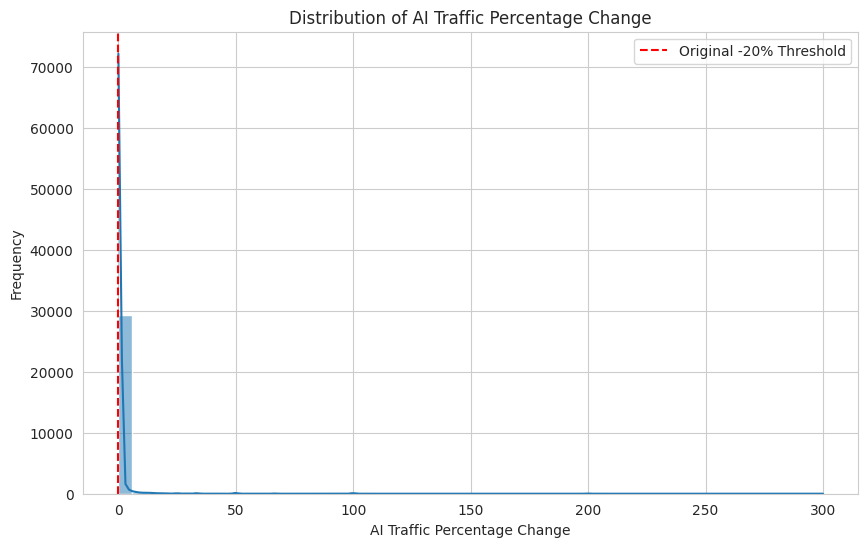

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Plot histogram of ai_traffic_pct
plt.figure(figsize=(10, 6))
sns.histplot(df['ai_traffic_pct'], bins=50, kde=True)
plt.title('Distribution of AI Traffic Percentage Change')
plt.xlabel('AI Traffic Percentage Change')
plt.ylabel('Frequency')
plt.axvline(-0.20, color='r', linestyle='--', label='Original -20% Threshold')
plt.legend()
plt.show()

## 4. Careful words: what I can and can't claim

What I Can Claim: "The model identifies statistical correlations between historical ranking trajectories, impression trends, CTR drift, and future traffic drops."

What I Can't Claim: "The model guarantees page-one recovery after a refresh, nor can it claim traffic decay is solely caused by a single Google algorithm update."

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.